**DESCRIPCIÓN**

- Se emplea base de datos de flujo extendida.
- El modelo contempla variabilidad en el contexto pero manteniendo un mismo tamaño de ventana.
- Se saca la presión como feature.

#### Exploratory Data Analysis

In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
measured_time = 42254

In [3]:
folder_path = '../data/isi2024/'
folder_path_diam = folder_path + 'diameter/'
folder_path_thick = folder_path + 'thickness/'

def process_rawdata(foldername, str_pos_name):
    data_by_ch = {}

    for file_name in os.listdir(foldername):
        file_path = os.path.join(foldername,file_name)
        
        if file_path.endswith('.csv'):
            x1 = str_pos_name
            ch_name = file_name[x1:x1 + 3]

            rawdata = pd.read_csv(
                file_path,
                skiprows=15,        # first 15 rows are metadata
                delimiter=',',
                header=0,
                encoding='utf-8',
                on_bad_lines='skip'
                )

        data_by_ch[ch_name] = rawdata.copy()
    
    return data_by_ch

idiam_by_ch = process_rawdata(folder_path_diam, str_pos_name = 21)
thick_by_ch = process_rawdata(folder_path_thick, str_pos_name = 25)


In [4]:
idiam_by_ch['E06'].head()

,Axial,Minimum,Maximum,Mean
0,2197.3500,103.8365,103.8500,103.8443
1,2198.2501,103.8455,103.8591,103.8533
2,2199.1500,103.8542,103.8669,103.8615
3,2200.0499,103.8620,103.8770,103.8706
4,2200.9500,103.8721,103.8806,103.8769


In [5]:
thick_by_ch['E06'].head()

,Axial,Minimum,Maximum,Mean
0,2225.9500,3.3245,4.1474,3.9024
1,2226.8501,3.3392,3.3955,3.3695
2,2227.7500,3.3568,3.4033,3.3845
3,2228.6499,3.3588,3.4099,3.3896
4,2229.5500,3.3577,3.4114,3.3895


Como el raw data del diámetro y del espesor tienen distintas coordenadas axiales para los puntos que se reportaron, se unifica tomando como referencia los puntos axiales de los diámetros. El espesor se interpola linealmente.

In [6]:
rawdata_by_ch = {}
for ch in idiam_by_ch:
    df = pd.DataFrame()
    df['Axial'] = idiam_by_ch[ch]['Axial']
    # Interpolamos los valores de Thick['Mean'] en los puntos de df['Axial']
    thick_axial = thick_by_ch[ch]['Axial']
    thick_mean = thick_by_ch[ch]['Mean']
    interpolated_thick = np.interp(df['Axial'], thick_axial, thick_mean)

    df['MeanDiam'] = idiam_by_ch[ch]['Mean']
    df['MeanThick'] = interpolated_thick
    
    rawdata_by_ch[ch] = df

In [7]:
rawdata_by_ch['E06'].head()

,Axial,MeanDiam,MeanThick
0,2197.3500,103.8443,3.9024
1,2198.2501,103.8533,3.9024
2,2199.1500,103.8615,3.9024
3,2200.0499,103.8706,3.9024
4,2200.9500,103.8769,3.9024


Filtramos la rawdata para quedarnos solo con la parte del tubo de presión.

In [8]:

channel_data = pd.read_csv(folder_path + 'channel_data.csv', skiprows=0)    # Here we load the channel lengths

channel_aface = {}
channel_lengths = {}
channel_idiam = {}
channel_thick = {}
bm_by_channel = {}
FilteredData_by_ch = {}
for ch in rawdata_by_ch:
    
    idx = channel_data.index[channel_data['channel'] == ch][0]
    ch_length = channel_data['length(mm)'][idx]
    ch_idiam = channel_data['inner_diam(mm)'][idx]
    ch_thick = channel_data['thick(mm)'][idx]
    channel_lengths[ch] = ch_length
    channel_idiam[ch] = ch_idiam
    channel_thick[ch] = ch_thick
    channel_aface[ch] = channel_data['a-face'][idx]
    df = rawdata_by_ch[ch]
    bm = channel_data['bm_near(mm)'][idx]   # Burnish mark position
    bm_by_channel[ch] = bm
    FilteredData_by_ch[ch] = df[(df['Axial'] >= bm) & (df['Axial'] <= bm + ch_length)]


In [9]:
FilteredData_by_ch['E06'].head()

,Axial,MeanDiam,MeanThick
148,2331.0499,103.7055,4.454610
149,2331.9500,103.7043,4.453444
150,2332.8500,103.7085,4.437945
151,2333.7501,103.7247,4.433678
152,2334.6500,103.7294,4.433989


In [10]:
FilteredData_by_ch['E06'].tail()

,Axial,MeanDiam,MeanThick
6978,8483.9498,103.9228,4.456559
6979,8484.8502,103.9213,4.456500
6980,8485.7008,103.9200,4.456422
6981,8486.5504,103.9188,4.456233
6982,8487.4498,103.9174,4.455967


Generamos un df incorporando los features Presión, Temperatura y Flujo Neutrónico. Además calculamos la tasa de variación del diámetro interno, la tasa de variación de espesor, la variación de diámetro externo y la tasa de variación de diámetro externo.

In [11]:

elongation_data = pd.read_csv(folder_path + 'fc_elongation_isi24.csv', skiprows=0)    # Here we load the channel elongation

data_by_ch = {}
for ch in FilteredData_by_ch:

    PT_idiameter_0 = channel_idiam[ch]      # Initial PT inner diameter in mm (as-built measure)
    PT_thick_0 = channel_thick[ch]          # Initial PT wall thickness in mm (as-built measure)
    PT_odiameter_0 = PT_idiameter_0 + 2 * PT_thick_0
    
    df = FilteredData_by_ch[ch]
    data_by_ch[ch] = df.copy()
    data_by_ch[ch]['Axial'] = (df['Axial'] - bm_by_channel[ch]) / 1e3                          # Origin at burnishmark and convert mm to m
    
    ptfile = f"..\\data\pressure&temperature\canales_BOL\\\{ch}.pt"             # Pressure and temperature data at beginning of life (Only pressure tube)
    PT_flxfile = f"..\\data\\flux\\pressure_tubes_extended\\{ch}.flx"           # Neutron flux data for pressure tube (> 1 MeV)

    pt_df = pd.read_csv(ptfile, delimiter='\t')
    flux_df = pd.read_csv(PT_flxfile, delimiter='\t', header=None)

    ch_length = channel_lengths[ch] / 1e3  # Convert mm to m
    ct_length = pt_df['Length(m)'].max()
    dl =  ch_length - ct_length
    pt_df['Length(m)'] = pt_df['Length(m)'] + dl / 2

    flux_coords_relativa = flux_df[0]
    flux_values = flux_df[1]
    flux_coords_real = flux_coords_relativa * ch_length

    if channel_aface[ch] == 'outlet':
        pt_df['Pressure (Pa)'] = pt_df['Pressure (Pa)'][::-1].reset_index(drop=True)
        pt_df['Temperature (ºC)'] = pt_df['Temperature (ºC)'][::-1].reset_index(drop=True)
        flux_values = flux_values[::-1]

    # Interpolación de presión y temperatura en las posiciones del DataFrame
    pressures = np.interp(data_by_ch[ch]['Axial'], pt_df['Length(m)'], pt_df['Pressure (Pa)'])
    temperatures = np.interp(data_by_ch[ch]['Axial'], pt_df['Length(m)'], pt_df['Temperature (ºC)'])
    
    # Interpolar flux en las posiciones axiales
    fluxes = np.interp(data_by_ch[ch]['Axial'], flux_coords_real, flux_values)

    idx = elongation_data.index[elongation_data['channel'] == ch][0]
    ch_elongation = elongation_data['elongation(mm)'][idx]
    
    data_by_ch[ch]['Pressure'] = pressures
    data_by_ch[ch]['Temperature'] = temperatures
    data_by_ch[ch]['Flux'] = fluxes
    data_by_ch[ch]['MeanRateDiam'] = (data_by_ch[ch]['MeanDiam'] - PT_idiameter_0) / (measured_time/(24*365))
    data_by_ch[ch]['MeanRateThick'] = (data_by_ch[ch]['MeanThick'] - PT_thick_0) / (measured_time/(24*365))
    data_by_ch[ch]['MeanRateOutDiam'] = ((data_by_ch[ch]['MeanDiam'] + 2 * data_by_ch[ch]['MeanThick']) - PT_odiameter_0) / (measured_time/(24*365))
    data_by_ch[ch]['MeanOutDiam'] = (data_by_ch[ch]['MeanDiam'] + 2 * data_by_ch[ch]['MeanThick'])
    data_by_ch[ch]['MeanRateElon'] = - (data_by_ch[ch]['MeanRateDiam'] / PT_idiameter_0) - (data_by_ch[ch]['MeanRateThick'] / PT_thick_0)
    

In [12]:
data_by_ch['E06'].head()

,Axial,MeanDiam,MeanThick,Pressure,Temperature,Flux,MeanRateDiam,MeanRateThick,MeanRateOutDiam,MeanOutDiam,MeanRateElon
148,0.00005,103.7055,4.454610,10672289.0,262.44,1.341480e+10,-0.005079,0.007175,0.009271,112.614721,-0.001574
149,0.00095,103.7043,4.453444,10672289.0,262.44,2.553920e+11,-0.005328,0.006934,0.008539,112.611189,-0.001517
150,0.00185,103.7085,4.437945,10672289.0,262.44,4.973422e+11,-0.004457,0.003720,0.002983,112.584390,-0.000799
151,0.00275,103.7247,4.433678,10672289.0,262.44,7.393194e+11,-0.001099,0.002836,0.004573,112.592056,-0.000631
152,0.00365,103.7294,4.433989,10672289.0,262.44,9.812428e+11,-0.000124,0.002900,0.005676,112.597378,-0.000655


In [13]:
data_by_ch['E06'].tail()

,Axial,MeanDiam,MeanThick,Pressure,Temperature,Flux,MeanRateDiam,MeanRateThick,MeanRateOutDiam,MeanOutDiam,MeanRateElon
6978,6.152950,103.9228,4.456559,10149618.0,309.72,1.089423e+12,0.039971,0.007579,0.055129,112.835918,-0.002100
6979,6.153850,103.9213,4.456500,10149618.0,309.72,8.478578e+11,0.039660,0.007567,0.054794,112.834300,-0.002094
6980,6.154701,103.9200,4.456422,10149618.0,309.72,6.196531e+11,0.039390,0.007551,0.054492,112.832844,-0.002088
6981,6.155550,103.9188,4.456233,10149618.0,309.72,3.917166e+11,0.039142,0.007512,0.054165,112.831267,-0.002077
6982,6.156450,103.9174,4.455967,10149618.0,309.72,1.504195e+11,0.038851,0.007457,0.053764,112.829334,-0.002062


In [14]:
def plot_channel(ch, column):

    fig, ax1 = plt.subplots()

    xcoord = data_by_ch[ch]['Axial'].to_numpy()
    pt_diam = data_by_ch[ch][column].to_numpy()
    main_label = 'PT'
    
    pt_pressure = data_by_ch[ch]['Pressure'].to_numpy()
    pt_temp = data_by_ch[ch]['Temperature'].to_numpy()
    pt_flux = data_by_ch[ch]['Flux'].to_numpy()
        
    target_mapping = {
        'MeanDiam': 'Inner Diameter (mm)',
        'MeanThick': 'Wall thickness (mm)',
        'MeanRateDiam': 'Inner Diameter rate (mm/EFPY)',
        'MeanRateThick': 'Wall thickness rate (mm/EFPY)',
        'MeanRateOutDiam': 'Outer Diameter rate (mm/EFPY)',
        'MeanOutDiam': 'Outer Diameter (mm)',
        'MeanRateElon': 'Elongation rate (mm/EFPY)'
    }
    ylabel_main = target_mapping[column]
    
    # Plot data
    ax1.plot(xcoord, pt_diam, 'r-', label=main_label)
    ax1.set_xlabel('x-coord (m)')
    ax1.set_ylabel(ylabel_main, color='r')
    ax1.tick_params(axis='y', labelcolor='r')

    # 2nd axis for temperature 
    ax2 = ax1.twinx()
    ax2.plot(xcoord, pt_temp, 'b-', label='Temperature')
    ax2.set_ylabel('Temperature (°C)', color='b')
    ax2.tick_params(axis='y', labelcolor='b')

    # 3rd axis for neutron flux
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(xcoord, pt_flux/1e13, 'g-', label='Flux')
    ax3.set_ylabel('Neutron Flux (x10^13 n/cm2*s)', color='g')
    ax3.tick_params(axis='y', labelcolor='g')

    # 4th axis for pressure
    ax4 = ax1.twinx()
    ax4.spines['right'].set_position(('outward', 120))
    ax4.plot(xcoord, pt_pressure/1e6, 'm-', label='Pressure')
    ax4.set_ylabel('Pressure (MPa)', color='m')
    ax4.tick_params(axis='y', labelcolor='m')
    
    plt.title(f'PT Channel {ch} at {measured_time:.2f} EFPH')
    plt.show()
    

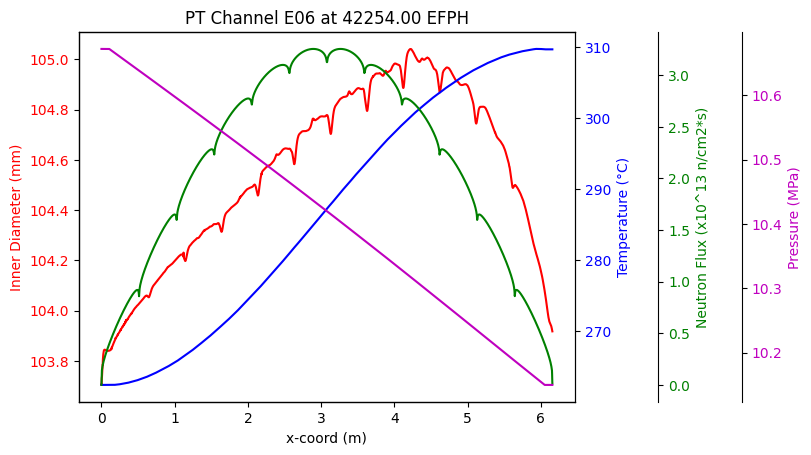

In [15]:
plot_channel('E06', column = 'MeanDiam')

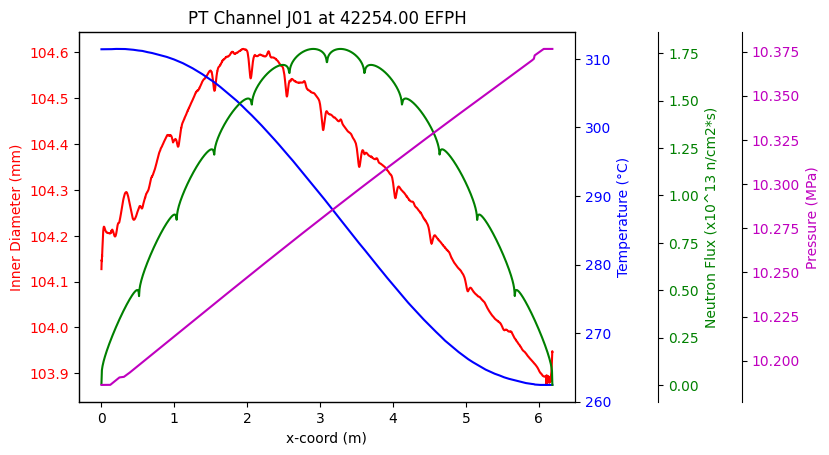

In [16]:
plot_channel('J01', column = 'MeanDiam')

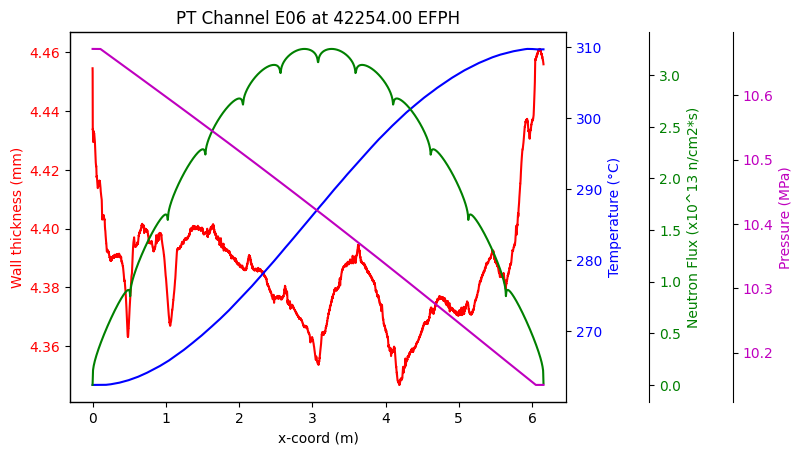

In [17]:
plot_channel('E06', column = 'MeanThick')

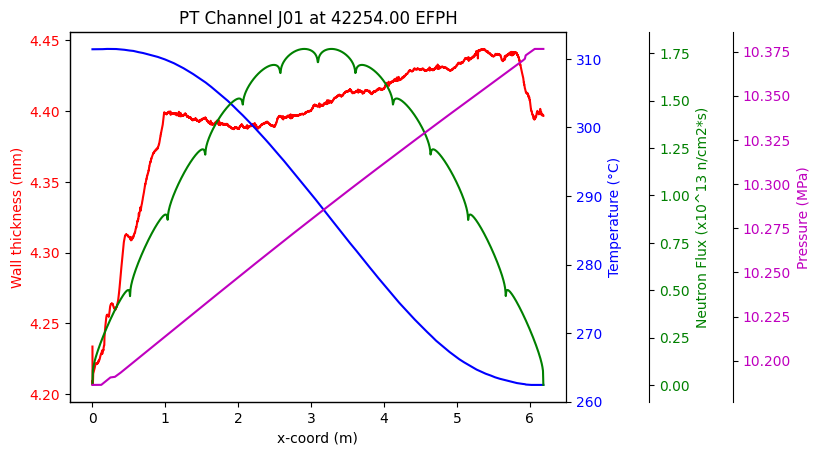

In [18]:
plot_channel('J01', column = 'MeanThick')

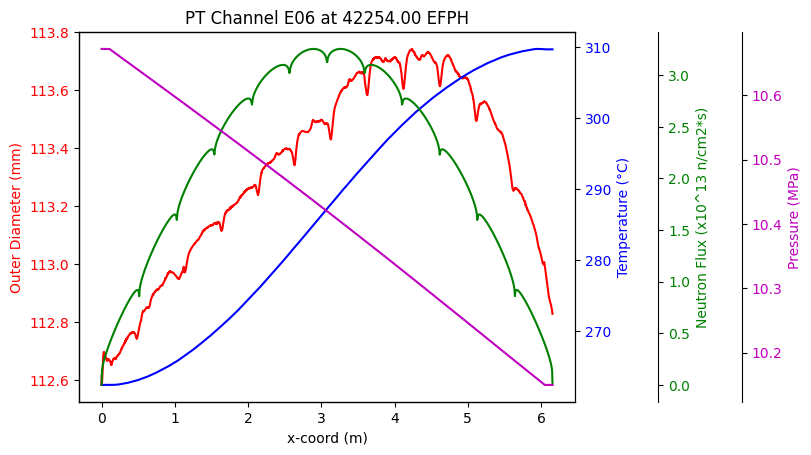

In [19]:
plot_channel('E06', column = 'MeanOutDiam')

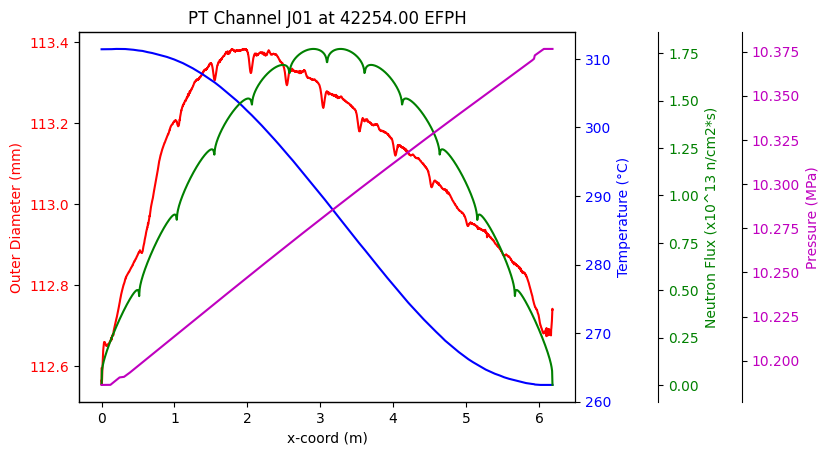

In [20]:
plot_channel('J01', column = 'MeanOutDiam')

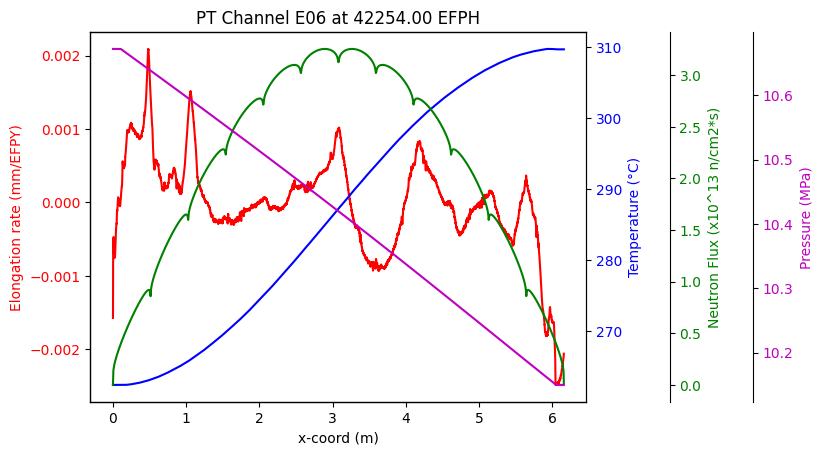

In [21]:
plot_channel('E06', column = 'MeanRateElon')

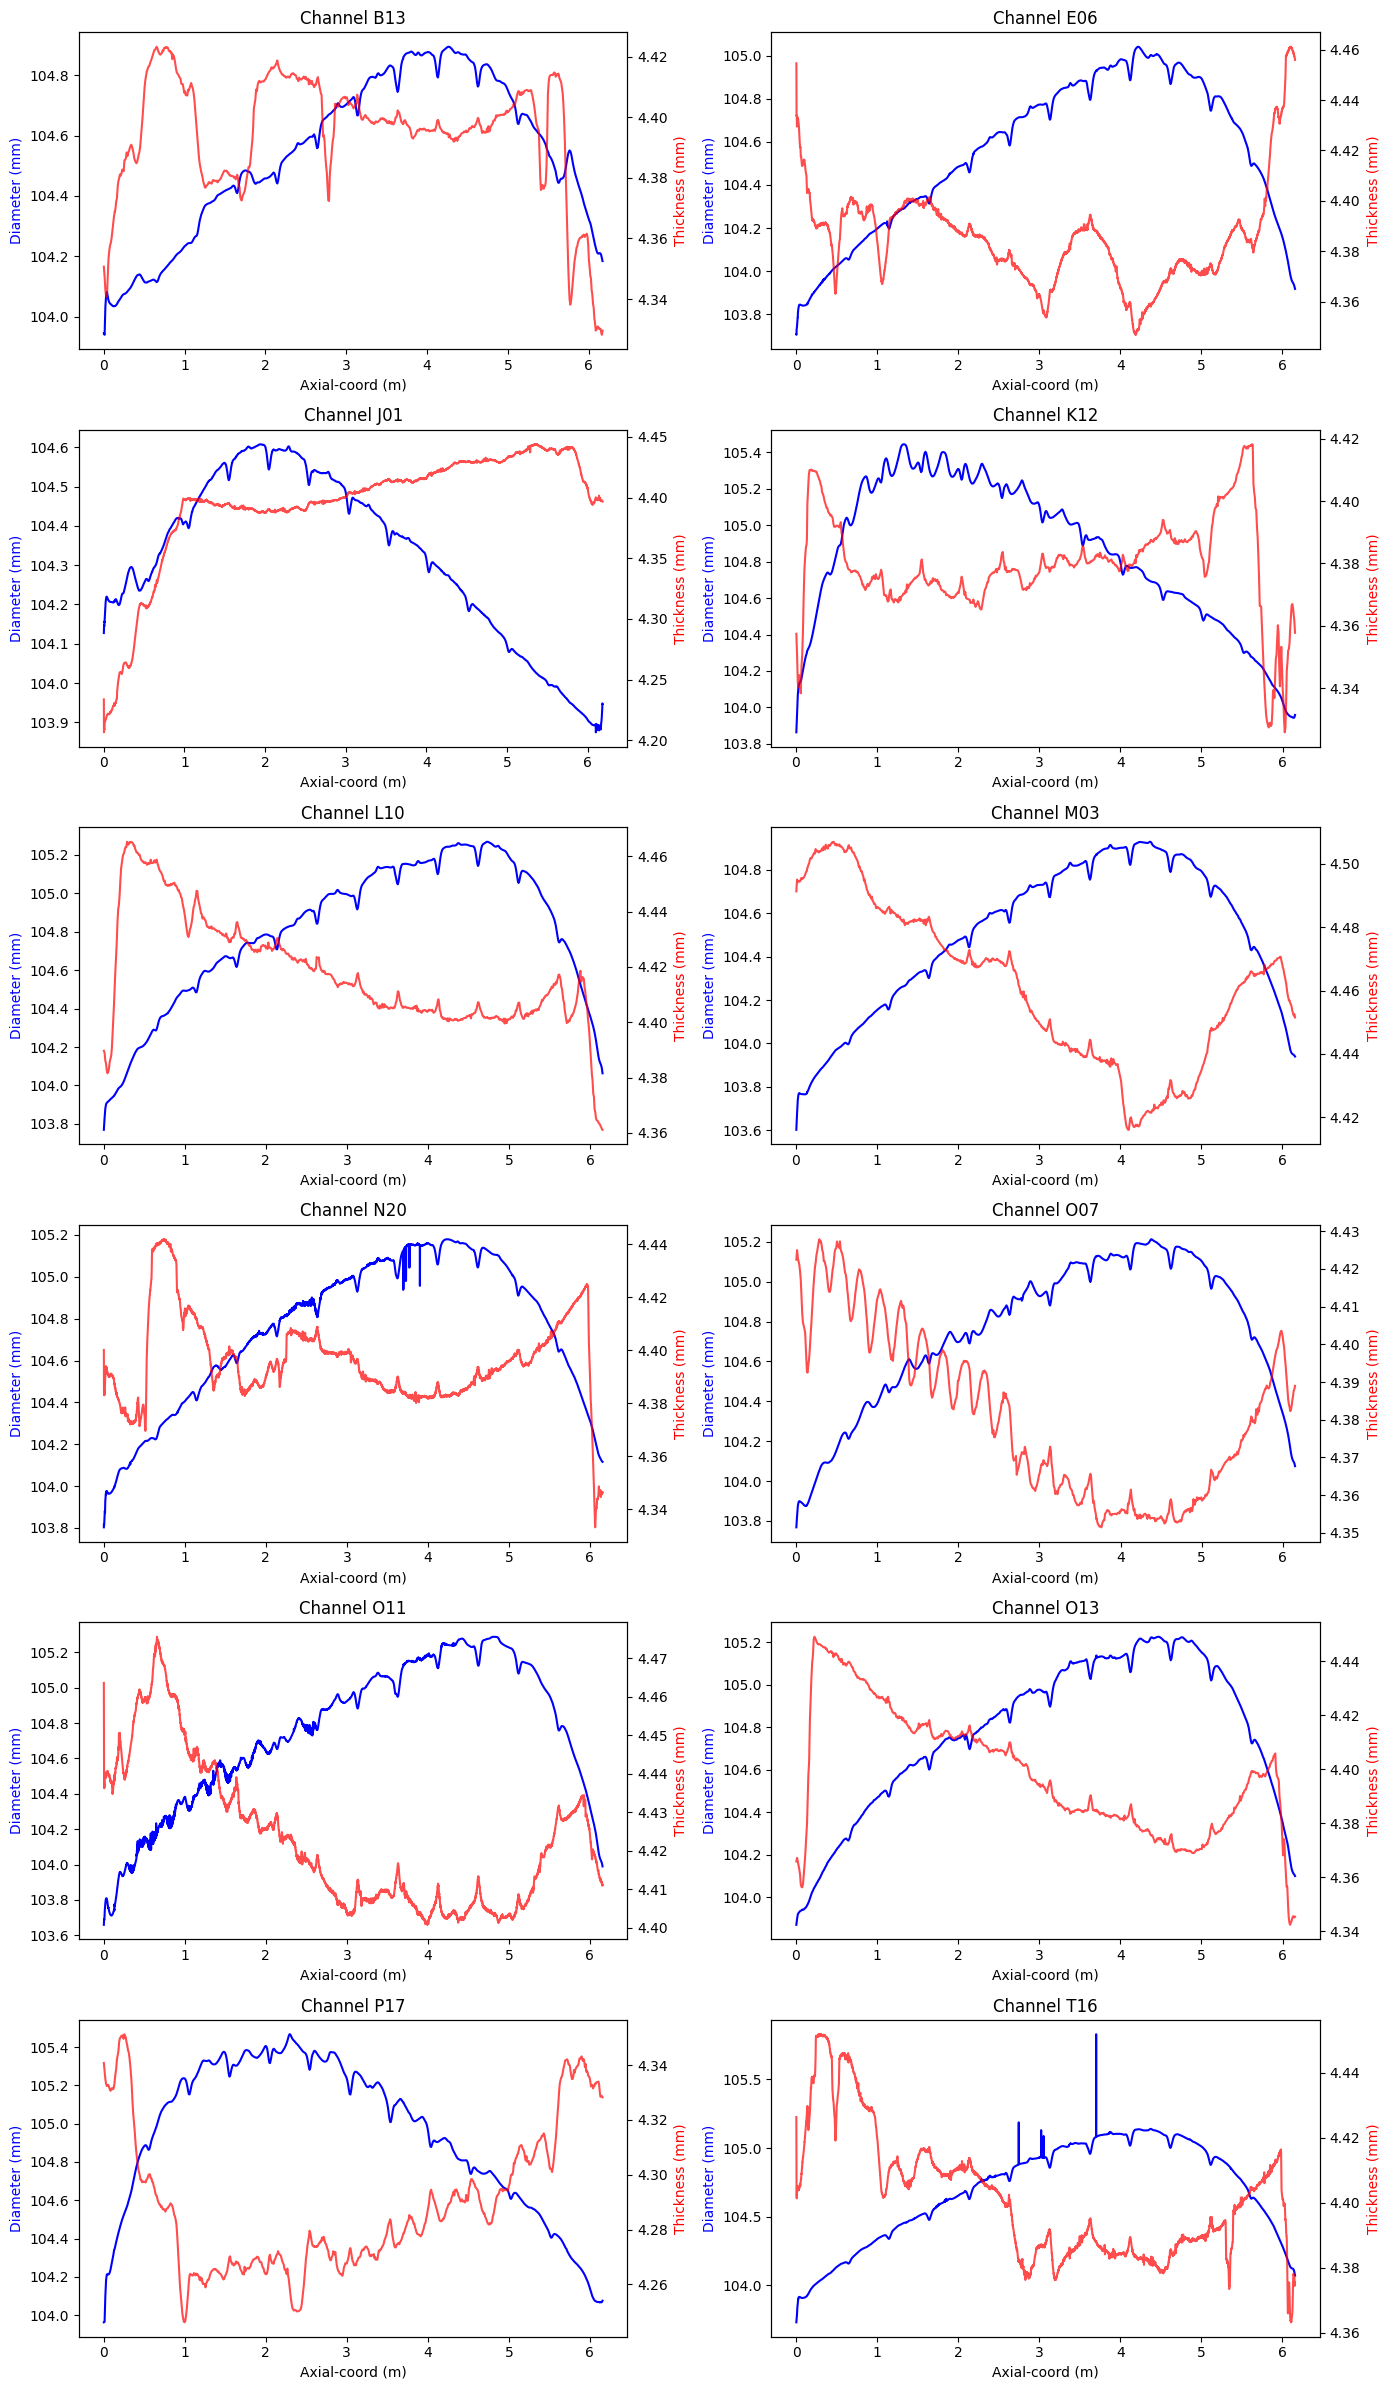

In [22]:
n_channels = len(data_by_ch)
cols = 2
rows = (n_channels + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 4*rows))
axes = axes.flatten() if n_channels > 1 else [axes]

for idx, (ch, df) in enumerate(data_by_ch.items()):
    ax = axes[idx]
    ax.plot(df['Axial'], df['MeanDiam'], label='Inner Diameter', color='blue')
    ax2 = ax.twinx()
    ax2.plot(df['Axial'], df['MeanThick'], label='Thicknes', color='red', alpha=0.7)
    
    ax.set_title(f'Channel {ch}')
    ax.set_xlabel('Axial-coord (m)')
    ax.set_ylabel('Diameter (mm)', color='blue')
    ax2.set_ylabel('Thickness (mm)', color='red')


for j in range(idx+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

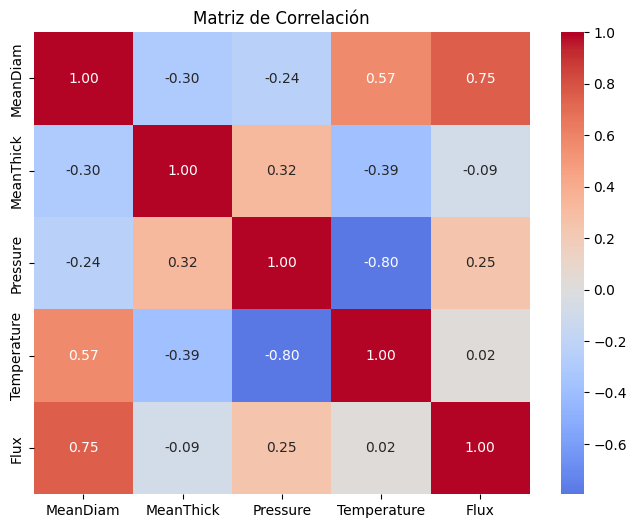

In [23]:
import seaborn as sns
df_corr = pd.concat(
    [df[['MeanDiam', 'MeanThick', 'Pressure', 'Temperature', 'Flux']].copy() 
     for df in data_by_ch.values()],
    ignore_index=True
)

# Si hay NaN, eliminar
df_corr = df_corr.dropna()

plt.figure(figsize=(8,6))
corr = df_corr.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title(f'Matriz de Correlación')
plt.show()

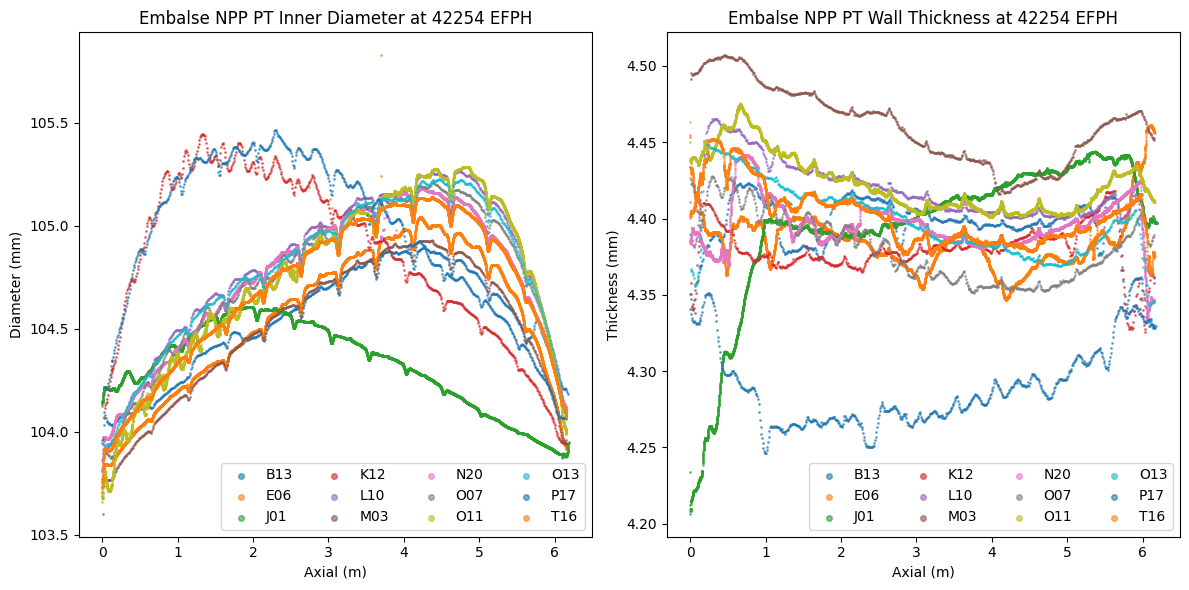

In [24]:
plt.figure(figsize=(12, 6))

for ch, df in data_by_ch.items():
    nominal_diam = channel_idiam[ch]
    nominal_thick = channel_thick[ch]
    
    plt.subplot(1, 2, 1)
    plt.scatter(df['Axial'], df['MeanDiam'], s=1, alpha=0.6, label=ch)
    
    plt.subplot(1, 2, 2)
    plt.scatter(df['Axial'], df['MeanThick'], s=1, alpha=0.6, label=ch)

plt.subplot(1, 2, 1)
plt.title(f'Embalse NPP PT Inner Diameter at {measured_time} EFPH')
plt.xlabel('Axial (m)')
plt.ylabel('Diameter (mm)')
plt.legend(loc='lower right', ncol=4, markerscale=4)

plt.subplot(1, 2, 2)
plt.title(f'Embalse NPP PT Wall Thickness at {measured_time} EFPH')
plt.xlabel('Axial (m)')
plt.ylabel('Thickness (mm)')
plt.legend(loc='lower right', ncol=4, markerscale=4)
plt.tight_layout()
plt.show()

#### Train/Validation/Test split

In [25]:
import random

nchannels_isi24 = len(data_by_ch.keys())

random.seed(42)  # fija la semilla
val_fraction = 0.1
test_fraction = 0.3
train_fraction = 1.0 - val_fraction - test_fraction

ntrain = int(nchannels_isi24 * train_fraction)
ntest = int(nchannels_isi24 * test_fraction)
nval = nchannels_isi24 - ntrain - ntest

channels_list = channel_data['channel'].tolist()

# Selecciona canales para entrenamiento sin repetición
train_channels_list = random.sample(channels_list, ntrain)

# Canales de validación y prueba
remaining_channels = [ch for ch in channels_list if ch not in train_channels_list]
test_channels_list = random.sample(remaining_channels, ntest)
val_channels_list = [ch for ch in remaining_channels if ch not in test_channels_list]

print(f'Cantidad de canales de ISI 24: {nchannels_isi24}')
print("")
print(f'Cantidad de canales de train: {ntrain}')
print(f'Listado de canales de train: {train_channels_list}')
print("")
print(f'Cantidad de canales de validation: {nval}')
print(f'Listado de canales de validation: {val_channels_list}')
print("")
print(f'Cantidad de canales de test: {ntest}')
print(f'Listado de canales de test: {test_channels_list}')

Cantidad de canales de ISI 24: 12

Cantidad de canales de train: 7
Listado de canales de train: ['P17', 'E06', 'B13', 'L10', 'K12', 'T16', 'N20']

Cantidad de canales de validation: 2
Listado de canales de validation: ['M03', 'O11']

Cantidad de canales de test: 3
Listado de canales de test: ['J01', 'O13', 'O07']


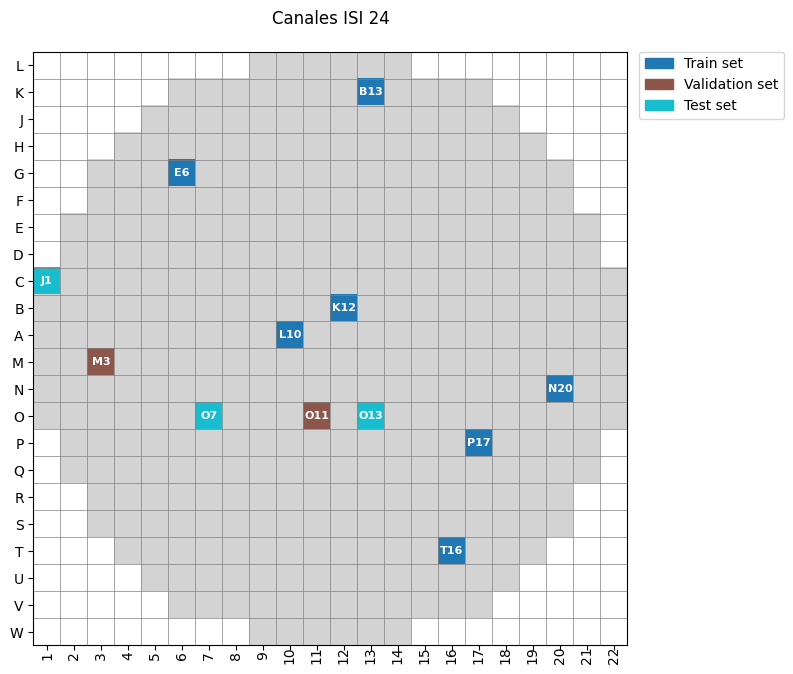

In [26]:
from utils import plot_channel_groups_map

groups_of_channels = {
    "Train set": train_channels_list,
    "Validation set": val_channels_list,
    "Test set": test_channels_list,
}

plot_channel_groups_map(groups_of_channels, title = 'Canales ISI 24')

#### Data processing in Torch format

In [27]:
import torch
from torch import nn
from torch import optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler

In [28]:

import random

class DiameterDataset(Dataset):
    """
    Dataset ON-THE-FLY con contexto variable.
    - Ventana: siempre (window_size, 4)
    - context_size ∈ [min_context, max_context] → aleatorio en cada __getitem__
    - Downsampling uniforme
    - NO precalcula ventanas → máxima diversidad
    - Compatible con num_workers=0
    """
    def __init__(
        self,
        data_dict,
        ch_list,
        window_size,
        min_context,
        max_context,
        feature_scaler=None,
        target_scaler=None,
        fit_scaler=False,
        target="center",
        data_stride=1,
        seed=42
    ):
        # === VALIDACIONES ===
        if not (window_size <= min_context <= max_context):
            raise ValueError("ERROR: window_size <= min_context <= max_context")
        for val, name in [(window_size, "window_size"), (min_context, "min_context"), (max_context, "max_context")]:
            if val % 2 == 0 or val < 3:
                raise ValueError(f"{name} debe ser impar y >= 3")
        if target != "center":
            raise ValueError("Solo target='center' soportado")

        # === PARÁMETROS ===
        self.data_dict = data_dict
        self.ch_list = ch_list
        self.window_size = window_size
        self.min_context = min_context
        self.max_context = max_context
        self.data_stride = data_stride
        self.seed = seed
        self.feature_scaler = feature_scaler
        self.target_scaler = target_scaler

        self.feature_cols = ['Axial', 'Temperature', 'Flux']
        self.target_col = 'MeanRateOutDiam'

        # === PRE-CALCULATE PADDED TENSORS (SHARED) ===
        self.feats_padded_list = []
        self.targets_list = []
        self.sample_indices = []  # (ch_idx, center_idx)
        self.lengths = []         # Para debug

        max_half = max_context // 2

        # === SCALERS (fit si es necesario) ===
        if fit_scaler:
            all_feats = []
            all_targs = []
            for ch in ch_list:
                df = data_dict[ch]
                feats = df[self.feature_cols].values.astype(np.float32)
                targs = df[self.target_col].values.astype(np.float32)
                all_feats.append(feats)
                all_targs.append(targs)
            all_feats = np.vstack(all_feats)
            all_targs = np.hstack(all_targs).reshape(-1, 1)
            self.feature_scaler = MinMaxScaler().fit(all_feats)
            self.target_scaler = MinMaxScaler().fit(all_targs)

        # === PRE-CALCULATE POR CANAL ===
        for ch_idx, ch in enumerate(ch_list):
            df = data_dict[ch]
            feats = df[self.feature_cols].values.astype(np.float32)
            targs = df[self.target_col].values.astype(np.float32)

            # Aplicar scalers
            if self.feature_scaler:
                feats = self.feature_scaler.transform(feats)
            if self.target_scaler:
                targs = self.target_scaler.transform(targs.reshape(-1, 1)).flatten()

            # === PAD CON np.pad (evita error de torch) ===
            feats_padded_np = np.pad(feats, ((max_half, max_half), (0, 0)), mode='edge')
            feats_padded = torch.from_numpy(feats_padded_np)

            targs_tensor = torch.from_numpy(targs)

            self.feats_padded_list.append(feats_padded)
            self.targets_list.append(targs_tensor)
            self.lengths.append(len(df))

            # Índices de muestras
            L = len(df)
            for i in range(0, L, data_stride):
                self.sample_indices.append((ch_idx, i))

    def __len__(self):
        return len(self.sample_indices)

    def __getitem__(self, idx):
        ch_idx, center_idx = self.sample_indices[idx]
        feats_padded = self.feats_padded_list[ch_idx]
        targets = self.targets_list[ch_idx]

        # === SAFE RANDOM (por worker + idx) ===
        worker_info = torch.utils.data.get_worker_info()
        if worker_info is not None:
            base_seed = worker_info.id + self.seed + idx
        else:
            base_seed = self.seed + idx
        rng = random.Random(base_seed)

        # === CONTEXTO ALEATORIO ===
        context_size = rng.randint(self.min_context, self.max_context)
        if context_size % 2 == 0:
            context_size -= 1
        half = context_size // 2

        offset = self.max_context // 2
        center_padded = center_idx + offset
        start = center_padded - half
        end = center_padded + half + 1

        window_real = feats_padded[start:end]  # (context_size, 4)

        # === DOWNSAMPLING ===
        if context_size > self.window_size:
            step = context_size / self.window_size
            ds_idx = torch.round(torch.arange(0, context_size, step)).long()[:self.window_size]
            window_final = window_real[ds_idx]
        else:
            window_final = window_real

        # === DEBUG INFO ===
        axial_vals = window_final[:, 0]
        axial_center = axial_vals[self.window_size // 2]
        delta_left = axial_center - axial_vals[0] if self.window_size > 1 else 0
        delta_right = axial_vals[-1] - axial_center if self.window_size > 1 else 0
        axial_range = (axial_vals[0].item(), axial_vals[-1].item())

        sample_info = (
            self.ch_list[ch_idx],
            center_idx,
            context_size,
            axial_range,
            float(delta_left),
            float(delta_right)
        )

        return window_final, targets[center_idx], sample_info

    # === DEBUG ===
    def sample(self, idx=0):
        X, y, info = self[idx]
        ch, center_idx, context_size, (a_min, a_max), d_left, d_right = info
        print(f"\n{'='*80}")
        print(f"SAMPLE #{idx}")
        print(f"   Channel       : {ch}")
        print(f"   Center idx    : {center_idx}")
        print(f"   Context size  : {context_size}")
        print(f"   Window size   : {self.window_size}")
        print(f"   Downsampled   : {context_size > self.window_size}")
        print(f"   Axial range   : [{a_min:.3f}, {a_max:.3f}] → Δtotal = {a_max-a_min:.3f}")
        print(f"   ΔAxial left   : {d_left:.3f}")
        print(f"   ΔAxial right  : {d_right:.3f}")
        print(f"   Target (scaled): {y.item():.6f}")
        print(f"\n   Final window (downsampled points):")
        df_X = pd.DataFrame(X.numpy(), columns=self.feature_cols)
        print(df_X.round(4).to_string(index=False))
        print(f"{'='*80}\n")

In [29]:
def custom_collate_fn(batch):
    """
    Mantiene sample_info como lista de tuplas (una por muestra)
    """
    features = torch.stack([item[0] for item in batch])
    targets = torch.stack([item[1] for item in batch])
    sample_info = [item[2] for item in batch]  # ← ¡Lista de 64 tuplas!
    return features, targets, sample_info

In [30]:
from types import SimpleNamespace
from torch.utils.data import DataLoader

cfg = SimpleNamespace(**{})

# === CONFIGURACIÓN ===
cfg.window_size = 21
cfg.min_context = cfg.window_size 
cfg.max_context = 121 
cfg.batch_size = 64

# === ENTRENAMIENTO ×3 ===
train_channels_aug = train_channels_list * 3

train_dataset = DiameterDataset(
    data_dict=data_by_ch,
    ch_list=train_channels_aug,
    window_size=cfg.window_size,
    min_context=cfg.min_context,
    max_context=cfg.max_context,
    fit_scaler=True,
    target="center",
    data_stride=1,
    seed=42
)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=custom_collate_fn
)

# === VALIDACIÓN ===
val_dataset = DiameterDataset(
    data_dict=data_by_ch,
    ch_list=val_channels_list,
    window_size=cfg.window_size,
    min_context=cfg.min_context,
    max_context=cfg.max_context,
    feature_scaler=train_dataset.feature_scaler,
    target_scaler=train_dataset.target_scaler,
    target="center",
    data_stride=1
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    drop_last=True,
)

# === TESTEO ===
test_dataset = DiameterDataset(
    data_dict=data_by_ch,
    ch_list=test_channels_list,
    window_size=cfg.window_size,
    min_context=cfg.min_context,
    max_context=cfg.max_context,
    feature_scaler=train_dataset.feature_scaler,
    target_scaler=train_dataset.target_scaler,
    target="center",
    data_stride=1
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024,
    shuffle=False,
    drop_last=False,
)

In [31]:
train_dataset.sample(idx=0)


SAMPLE #0
   Channel       : P17
   Center idx    : 0
   Context size  : 101
   Window size   : 21
   Downsampled   : True
   Axial range   : [0.000, 0.066] → Δtotal = 0.066
   ΔAxial left   : 0.000
   ΔAxial right  : 0.066
   Target (scaled): 0.178632

   Final window (downsampled points):
 Axial  Temperature   Flux
0.0003       0.9751 0.0146
0.0003       0.9751 0.0146
0.0003       0.9751 0.0146
0.0003       0.9751 0.0146
0.0003       0.9751 0.0146
0.0003       0.9751 0.0146
0.0003       0.9751 0.0146
0.0003       0.9751 0.0146
0.0003       0.9751 0.0146
0.0003       0.9751 0.0146
0.0003       0.9751 0.0146
0.0048       0.9751 0.0702
0.0122       0.9751 0.1033
0.0196       0.9754 0.1307
0.0235       0.9759 0.1440
0.0309       0.9759 0.1681
0.0383       0.9751 0.1908
0.0456       0.9743 0.2120
0.0530       0.9727 0.2320
0.0589       0.9711 0.2468
0.0663       0.9688 0.2637



In [32]:
for features, target, sample_info in train_loader:
    print(f"Input shape : {features.shape}")      # (64, 21, 4)
    print(f"Target shape: {target.shape}")        # (64,)
    print(f"Sample info len: {len(sample_info)}") # → debe ser 64
    print(f"First info: {sample_info[0]}")        # → ('B13', 150, 121, (2.1, 8.8), 6.7, 6.7)
    break

Input shape : torch.Size([64, 21, 3])
Target shape: torch.Size([64])
Sample info len: 64
First info: ('T16', 4218, 89, (0.6074984669685364, 0.6198960542678833), 0.006117761135101318, 0.0062798261642456055)


### Modelling

In [33]:
# ========================================
# CONFIGURACIÓN
# ========================================

cfg.lr = 1e-3
cfg.epochs = 200


In [34]:
# ========================================
# MODELO CNN 1D (para target="center")
# ========================================

# ===================================================================
# BLOQUE DE CONVOLUCIÓN
# ===================================================================
def conv_block(in_channels, out_channels, kernel_size=3, dropout=0.0):
    """
    Bloque convolucional para regresión 1D.
    - Mantiene dimensión espacial (padding='same')
    - Sin pooling → fully convolutional
    - ReLU + Dropout opcional
    """
    padding = kernel_size // 2
    return nn.Sequential(
        nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding),
        nn.BatchNorm1d(out_channels),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout, inplace = False) if dropout > 0 else nn.Identity()
    )
class CNN1DRegressor(nn.Module):
    def __init__(self, input_channels=3, nlayers=3, dropout=0.2):
        super().__init__()
        layers = []
        out_ch = 32
        in_ch = input_channels
        
        for i in range(nlayers):
            layers.append(conv_block(in_ch, out_ch, kernel_size=3, dropout=dropout))
            in_ch = out_ch
            if i < nlayers - 1:
                out_ch *= 2
        
        self.conv_blocks = nn.Sequential(*layers)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(in_ch, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)              # (B, W, 4) → (B, 4, W)
        x = self.conv_blocks(x)             # (B, 128, W)
        x = self.global_pool(x).flatten(1)  # (B, 128)
        x = self.fc(x)                      # (B, 1)
        return x.squeeze(-1)                # (B,)

In [35]:
# ========================================
# DISPOSITIVO
# ========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [36]:
# ========================================
# ENTRENAMIENTO + VALIDACIÓN + EARLY STOPPING
# ========================================
model = CNN1DRegressor(input_channels=3, nlayers=4, dropout=0.3).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=1e-4)

# --- Scheduler SIN verbose (evita warning) ---
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5  # verbose=False por defecto
)

# --- Entrenamiento ---
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print("Iniciando entrenamiento...")
for epoch in range(cfg.epochs):
    # --- Train ---
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch, sample_info in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)
    train_loss = epoch_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # --- Val ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch, sample_info in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    # --- SCHEDULER: Ajusta LR ---
    scheduler.step(val_loss)

    # --- OBTENER LR ACTUAL (forma moderna y sin warning) ---
    current_lr = optimizer.param_groups[0]['lr']  # ← Recomendado

    print(f"Epoch {epoch+1}/{cfg.epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {current_lr:.2e}")

Iniciando entrenamiento...
Epoch 1/200 | Train Loss: 0.004586 | Val Loss: 0.007629 | LR: 1.00e-03
Epoch 2/200 | Train Loss: 0.001518 | Val Loss: 0.010857 | LR: 1.00e-03
Epoch 3/200 | Train Loss: 0.001275 | Val Loss: 0.005768 | LR: 1.00e-03
Epoch 4/200 | Train Loss: 0.001172 | Val Loss: 0.005934 | LR: 1.00e-03
Epoch 5/200 | Train Loss: 0.001117 | Val Loss: 0.003394 | LR: 1.00e-03
Epoch 6/200 | Train Loss: 0.001022 | Val Loss: 0.004933 | LR: 1.00e-03
Epoch 7/200 | Train Loss: 0.001003 | Val Loss: 0.005628 | LR: 1.00e-03
Epoch 8/200 | Train Loss: 0.001024 | Val Loss: 0.007064 | LR: 1.00e-03
Epoch 9/200 | Train Loss: 0.000971 | Val Loss: 0.008260 | LR: 1.00e-03
Epoch 10/200 | Train Loss: 0.000939 | Val Loss: 0.007674 | LR: 1.00e-03
Epoch 11/200 | Train Loss: 0.000911 | Val Loss: 0.004241 | LR: 5.00e-04
Epoch 12/200 | Train Loss: 0.000761 | Val Loss: 0.003523 | LR: 5.00e-04
Epoch 13/200 | Train Loss: 0.000781 | Val Loss: 0.006290 | LR: 5.00e-04
Epoch 14/200 | Train Loss: 0.000756 | Val Loss

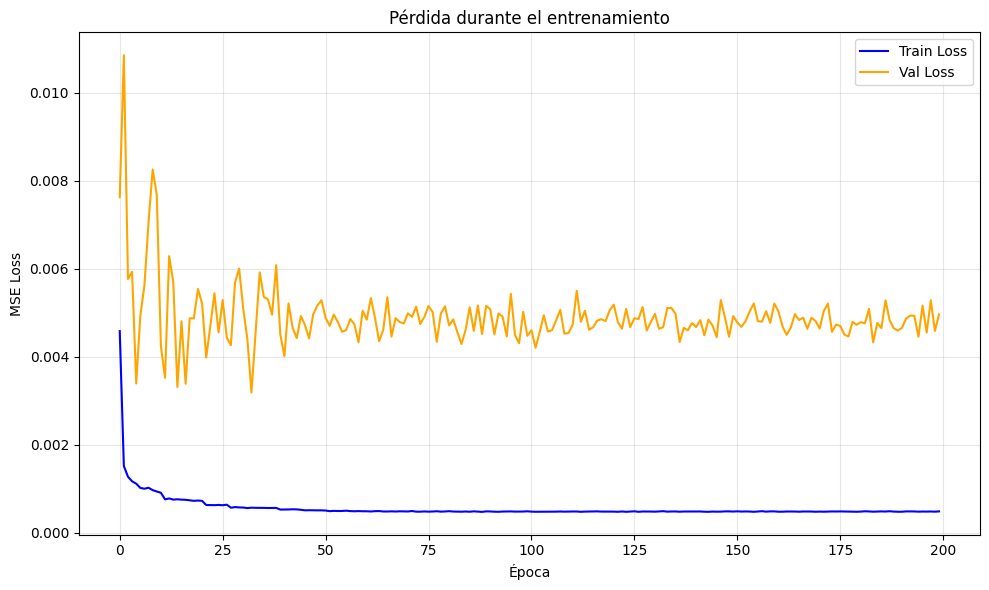

In [37]:
# ========================================
# GRÁFICO: Pérdida vs Épocas
# ========================================
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.title('Pérdida durante el entrenamiento')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
import joblib
import json

# ========================================
# GUARDAR: SCALER + MODELO + CONFIG COMPLETA
# ========================================
directory = '..\\persistency'
os.makedirs(directory, exist_ok=True)

# -------------------------------
# 1. SCALER DE FEATURES
# -------------------------------
feature_scaler_path = os.path.join(directory, 'OuterDiam_model1_feature_scaler_v5.pkl')
joblib.dump(train_dataset.feature_scaler, feature_scaler_path)
print(f"Feature scaler guardado en: {feature_scaler_path}")

# -------------------------------
# 2. SCALER DEL TARGET (MeanRateOutDiam)
# -------------------------------
target_scaler_path = os.path.join(directory, 'OuterDiam_model1_target_scaler_v5.pkl')
joblib.dump(train_dataset.target_scaler, target_scaler_path)
print(f"Target scaler guardado en: {target_scaler_path}")

# -------------------------------
# 3. CONFIGURACIÓN COMPLETA
# -------------------------------
config_to_save = {
    "window_size": train_dataset.window_size,
    "min_context": train_dataset.min_context,
    "max_context": train_dataset.max_context,
    "data_stride": train_dataset.data_stride,
    "feature_cols": train_dataset.feature_cols,
    "target_col": train_dataset.target_col,
    "model_class": "CNN1DRegressor",
    "model_params": {
        "input_channels": 3,
        "nlayers": getattr(model, 'nlayers', 4),
        "dropout": getattr(model, 'dropout', 0.3) if hasattr(model, 'dropout') else 0.3
    },
    "version": "v5",
    "saved_at": __import__('datetime').datetime.now().isoformat()
}

config_path = os.path.join(directory, 'OuterDiam_model1_cfg_v5.json')
with open(config_path, 'w') as f:
    json.dump(config_to_save, f, indent=2)
print(f"Configuración COMPLETA guardada en: {config_path}")

# -------------------------------
# 4. MODELO (state_dict)
# -------------------------------
model_path = os.path.join(directory, 'OuterDiam_model1_param_v5.pth')
torch.save(model.state_dict(), model_path)
print(f"Modelo guardado en: {model_path}")

Feature scaler guardado en: ..\persistency\OuterDiam_model1_feature_scaler_v5.pkl
Target scaler guardado en: ..\persistency\OuterDiam_model1_target_scaler_v5.pkl
Configuración COMPLETA guardada en: ..\persistency\OuterDiam_model1_cfg_v5.json
Modelo guardado en: ..\persistency\OuterDiam_model1_param_v5.pth


In [39]:
def plot_channel(
    test_tube_idx,
    test_channels_list,
    test_dataset,      # <-- on-the-fly
    model,
    device,
    train_dataset,     # <-- para el target_scaler
    data_by_ch
):
    # ========================================
    # TEST: Predicción completa en un tubo
    # ========================================
    model.eval()
    test_tube_ch = test_channels_list[test_tube_idx]
    test_tube_df = data_by_ch[test_tube_ch].copy()

    # Obtener índices originales del tubo
    original_positions = test_tube_df.index
    true_diam = test_tube_df['MeanOutDiam'].values

    # Reconstruir predicciones (una por punto central)
    preds = np.full(len(true_diam), np.nan)

    with torch.no_grad():
        for i in range(len(test_dataset)):
            # ---- NUEVO: obtenemos X, y y sample_info con __getitem__ ----
            X_win, _, sample_info = test_dataset[i]
            ch, center_idx, *_ = sample_info

            if ch != test_tube_ch:
                continue

            # ---- NUEVO: añadir dimensión batch ----
            X_win = X_win.unsqueeze(0).to(device)   # (1, window_size, 4)

            pred = model(X_win).cpu().item()
            pred_unscaled = train_dataset.target_scaler.inverse_transform([[pred]])[0][0]
            preds[center_idx] = pred_unscaled

    PT_idiameter_0 = channel_idiam[test_tube_ch]      # Initial PT inner diameter in mm (as-built measure)
    PT_thick_0 = channel_thick[test_tube_ch]          # Initial PT wall thickness in mm (as-built measure)
    PT_odiameter_0 = PT_idiameter_0 + 2 * PT_thick_0

    pred_diam = PT_odiameter_0 + preds * (measured_time / (24 * 365))

    # ========================================
    # GRÁFICO: Real vs Predicho
    # ========================================
    plt.figure(figsize=(8, 4))
    plt.plot(original_positions, true_diam, 'o-', label='Measured', color='blue', markersize=3)
    plt.plot(original_positions, pred_diam, 's--', label='Predicted', color='red', markersize=3)
    plt.xlabel('Posición Axial (mm)')
    plt.ylabel('Outer Diameter (mm)')
    plt.title(f'Measured vs Predicted - Channel: {test_tube_ch}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(112, 115)
    plt.tight_layout()
    plt.show()

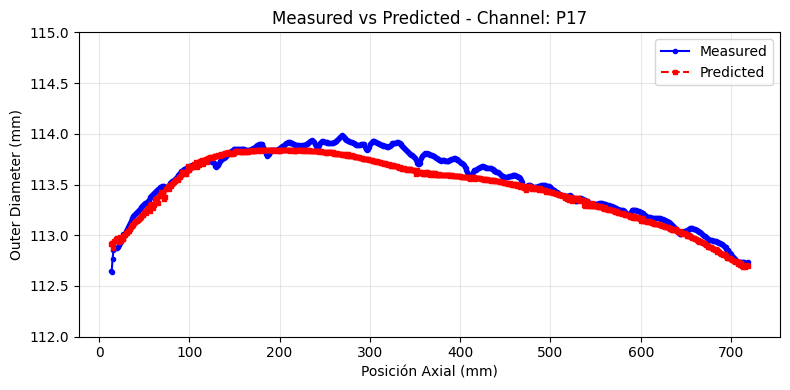

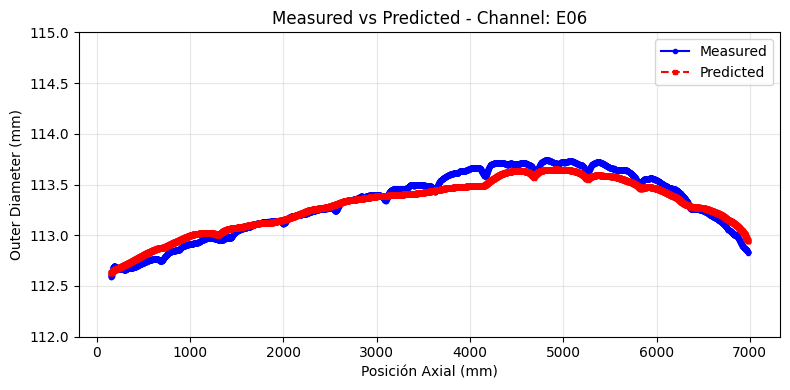

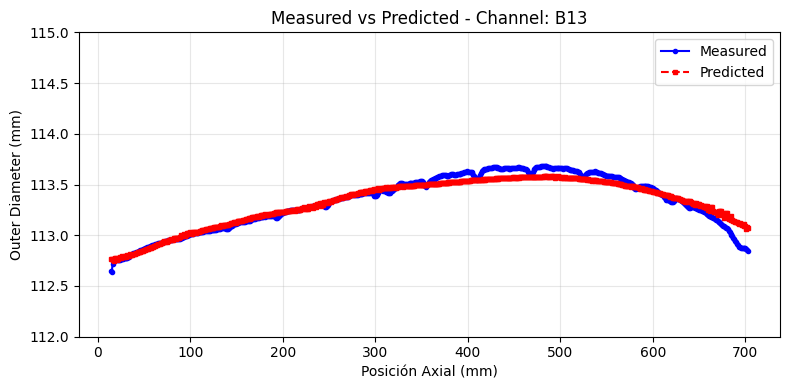

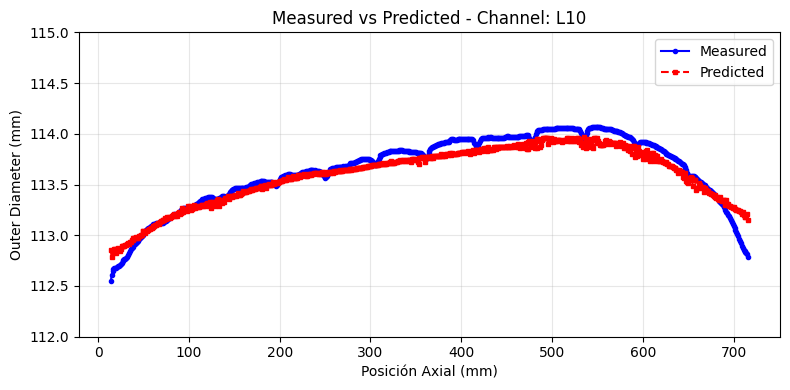

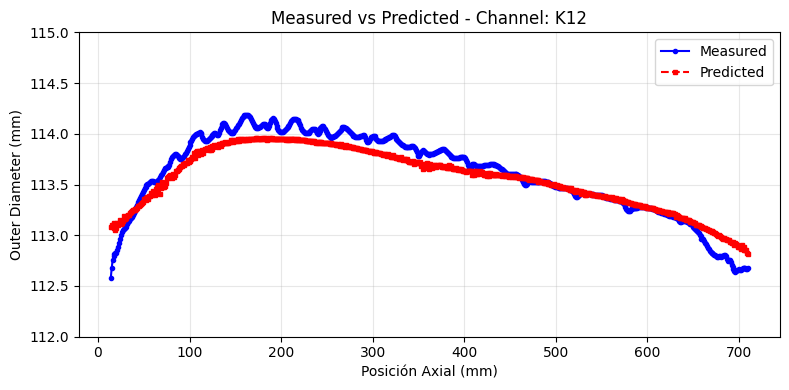

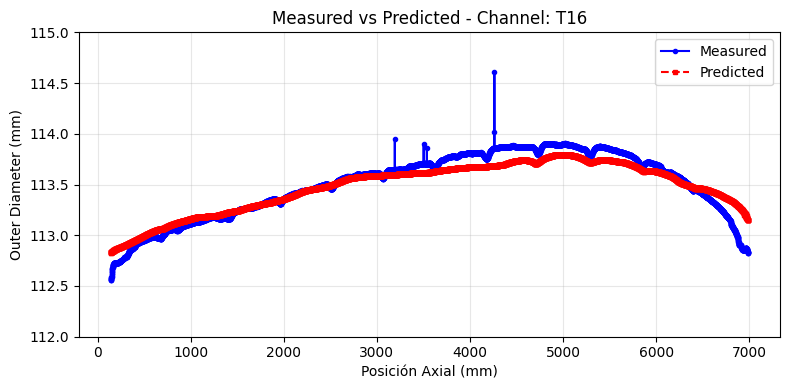

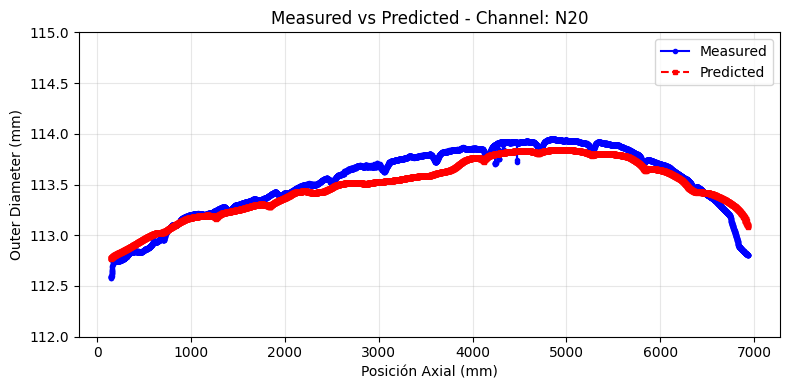

In [40]:
for ch_i in range(ntrain):
    plot_channel(
        ch_i,
        train_channels_list,
        train_dataset,      # <-- on-the-fly
        model,
        device,
        train_dataset,      # <-- para el scaler
        data_by_ch
    )

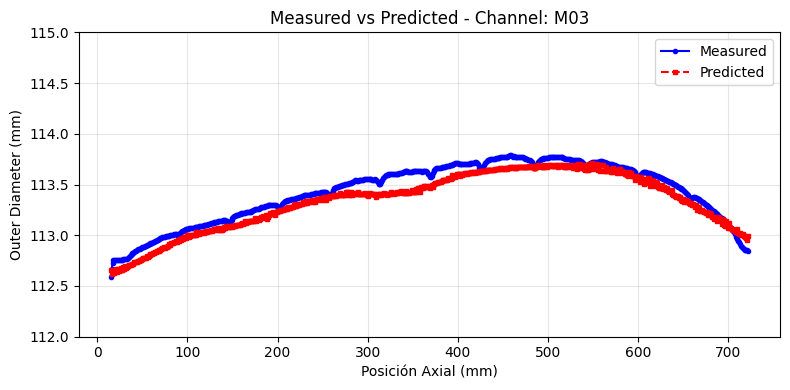

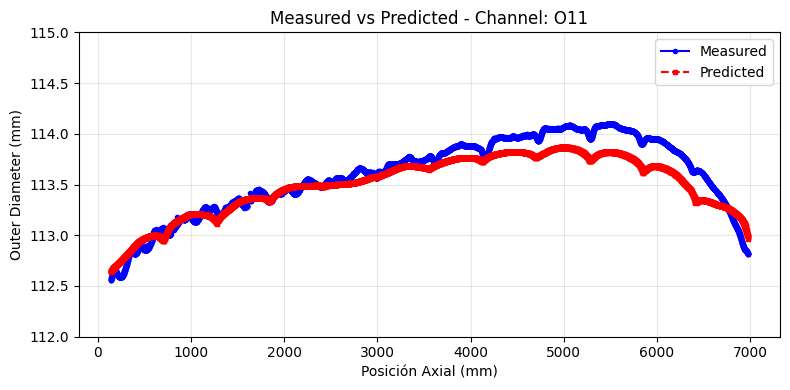

In [41]:
for ch_i in range(nval):
    plot_channel(
        ch_i,
        val_channels_list,
        val_dataset,
        model,           # Añadido
        device,          # Añadido
        train_dataset,   # Añadido (para el scaler)
        data_by_ch       # Añadido
    )

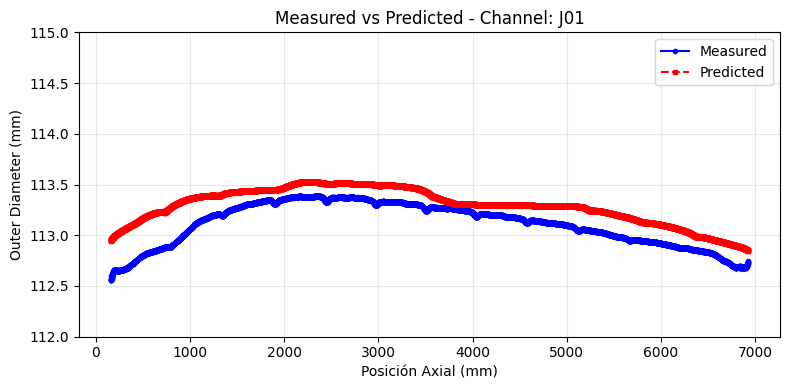

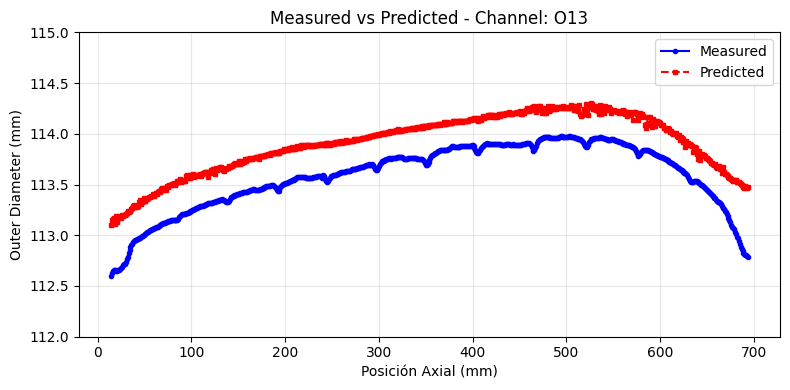

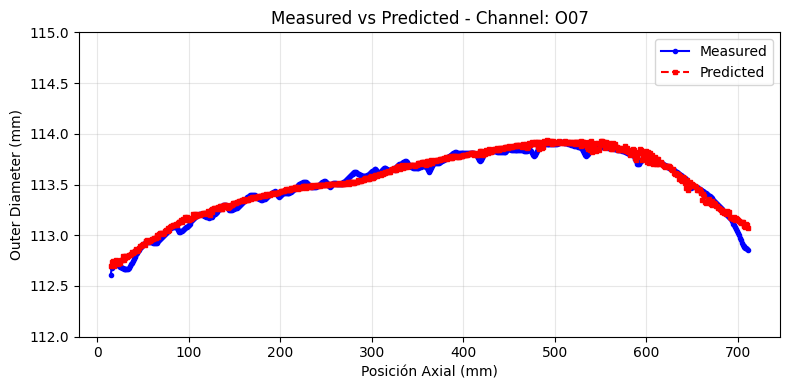

In [42]:
for ch_i in range(ntest):
    plot_channel(
        ch_i,
        test_channels_list,
        test_dataset,
        model,           # Añadido
        device,          # Añadido
        train_dataset,   # Añadido (para el scaler)
        data_by_ch       # Añadido
    )